In [15]:
import torch
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

In [2]:
train_augmentation = transforms.Compose([

    transforms.RandomRotation(25),

    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.RandomResizedCrop(
        size=128
    ),

    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    )

])

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=128, batch_size=128, train_transform=train_augmentation)

In [4]:
def train_model(optimizer_name):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = nn.Sequential(

        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),

        nn.Linear(64 * 32 * 32, 128),
        nn.ReLU(),

        nn.Linear(128, NUM_CLASSES)

    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.001,
            momentum=0.9
        )

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.001
        )

    epochs = 12

    losses = []
    accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss

        losses.append(epoch_loss)

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        accuracy = 100 * correct / total

        accuracies.append(accuracy)

        print(
            f"{optimizer_name} | "
            f"Epoch {epoch+1} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Validation Accuracy: {accuracy:.2f}%"
        )

    return model, losses, accuracies

In [8]:
def metrics(model, test_loader, device):

    model.eval()

    cm = np.zeros((43, 43), dtype=int)

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predictions = torch.max(outputs, 1)

            for label, prediction in zip(labels, predictions):

                cm[label.item(), prediction.item()] += 1

    np.set_printoptions(threshold=np.inf)

    print("Matriz de Confusão:")
    print(cm)

    acc_class = [0 for _ in GTSRB_CLASSES]

    print("\nAcurácia por classe:")

    for i in range(43):

        total_class = np.sum(cm[i, :])

        if total_class > 0:

            acc = 100 * (cm[i, i] / total_class)

        else:

            acc = 0

        acc_class[i] = acc

        print(f"Classe {i}: {acc:.2f}%")

    worst_class = acc_class.index(min(acc_class))
    best_class = acc_class.index(max(acc_class))

    print(
        f"\nWorst class: {worst_class} "
        f"- {min(acc_class):.2f}%"
    )

    print(
        f"Best class: {best_class} "
        f"- {max(acc_class):.2f}%"
    )

    return cm, acc_class

In [13]:
def generate_predictions(model):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.eval()

    predictions_list = []

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            predictions_list.extend(
                predictions.cpu().numpy()
            )
        metrics(model, test_loader, device)
    return predictions_list

In [7]:
model_adam, losses_adam, accs_adam = train_model("Adam")

c:\Users\rafae\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Adam | Epoch 1 | Loss: 741.9124 | Validation Accuracy: 7.00%
Adam | Epoch 2 | Loss: 567.7371 | Validation Accuracy: 8.58%
Adam | Epoch 3 | Loss: 541.8137 | Validation Accuracy: 11.28%
Adam | Epoch 4 | Loss: 504.7263 | Validation Accuracy: 17.96%
Adam | Epoch 5 | Loss: 484.8544 | Validation Accuracy: 19.35%
Adam | Epoch 6 | Loss: 480.0277 | Validation Accuracy: 21.62%
Adam | Epoch 7 | Loss: 476.1198 | Validation Accuracy: 22.20%
Adam | Epoch 8 | Loss: 472.2190 | Validation Accuracy: 19.78%
Adam | Epoch 9 | Loss: 470.1198 | Validation Accuracy: 19.76%
Adam | Epoch 10 | Loss: 466.7950 | Validation Accuracy: 20.21%
Adam | Epoch 11 | Loss: 466.3910 | Validation Accuracy: 21.85%
Adam | Epoch 12 | Loss: 462.5084 | Validation Accuracy: 25.58%


In [14]:
print('Metrics for adam')
y_pred_adam = generate_predictions(model_adam)

Metrics for adam
Matriz de Confusão:
[[  0   0  59   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0 664   0   0  22   0   0   0   0  21   0   0  10   0   0   0   2
    0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0 636   0   0   7   0   0   0   0  19   0  29  44   0   0   0  15
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0 305   0   0  41   0   0   0   0  24   0   4  65   0   0   0   0
    0   0   0   0   0   0   0  11   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0 379   0   0 140   0   0   0   0  34   0  19  84   0   0   0   0
    0   0   0   0   0   0   0   4   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0 477   0   0  72   0   0   0   0  39   0   0  30   0   0   

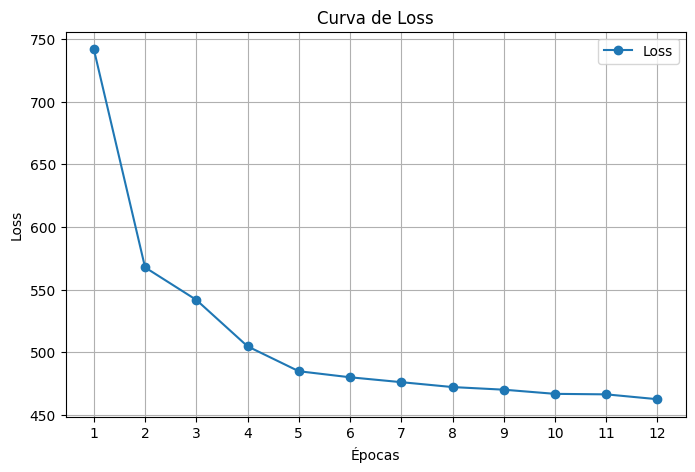

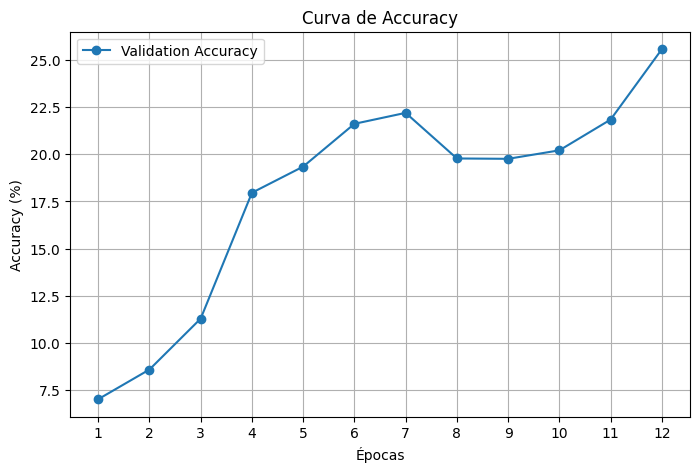

In [19]:
epochs_range = range(1, 13)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    losses_adam,
    marker='o',
    label='Loss'
)

plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    accs_adam,
    marker='o',
    label='Validation Accuracy'
)

plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()